In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
customers = pd.read_csv("../data/customers_cleaned.csv")
loans = pd.read_csv("../data/loans_cleaned.csv")
defaults = pd.read_csv("../data/defaults_cleaned.csv")

In [3]:
loan_default_flag = loans.merge(
    defaults[['Loan_ID']],
    on='Loan_ID',
    how='left',
    indicator=True
)

loan_default_flag['Default_Flag'] = (
    loan_default_flag['_merge'] == 'both'
).astype(int)

In [5]:
customer_profile = customers.merge(
    loan_default_flag[['Customer_ID', 'Default_Flag']],
    on='Customer_ID',
    how='left'
)

customer_profile['Default_Flag'] = customer_profile['Default_Flag'].fillna(0)

In [7]:
customer_profile['Income_Segment'] = pd.qcut(
    customer_profile['Annual_Income'],
    q=3,
    labels=['Low Income', 'Middle Income', 'High Income']
)

In [8]:
customer_profile['Credit_Segment'] = pd.cut(
    customer_profile['Credit_Score'],
    bins=[300, 600, 700, 850],
    labels=['Low Credit', 'Medium Credit', 'High Credit']
)

In [9]:
income_default = customer_profile.groupby('Income_Segment')['Default_Flag'].mean()
credit_default = customer_profile.groupby('Credit_Segment')['Default_Flag'].mean()

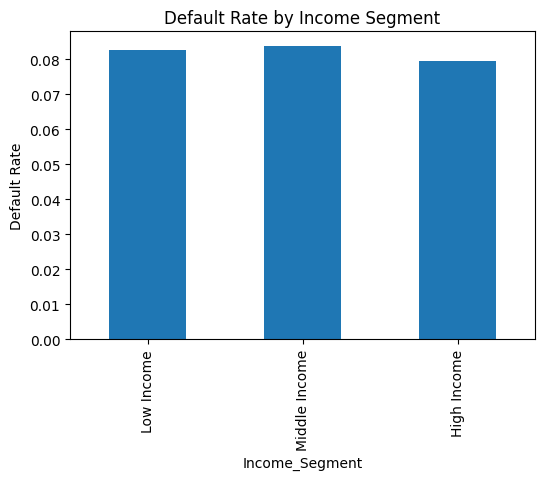

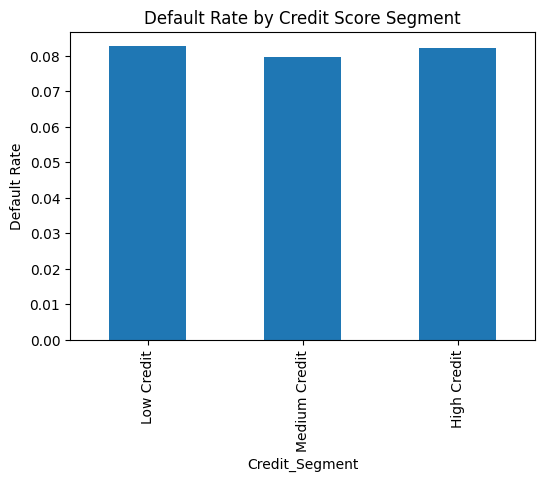

In [10]:
income_default.plot(kind='bar', figsize=(6,4))
plt.title("Default Rate by Income Segment")
plt.ylabel("Default Rate")
plt.show()

credit_default.plot(kind='bar', figsize=(6,4))
plt.title("Default Rate by Credit Score Segment")
plt.ylabel("Default Rate")
plt.show()

In [11]:
high_risk = customer_profile[
    (customer_profile['Credit_Segment'] == 'Low Credit') &
    (customer_profile['Income_Segment'] == 'Low Income')
]

high_value = customer_profile[
    (customer_profile['Credit_Segment'] == 'High Credit') &
    (customer_profile['Income_Segment'] == 'High Income')
]

### Task 5 – Customer Segmentation Insights

- Low income and low credit score customers exhibit the highest default rates
- High credit score customers show strong repayment behavior irrespective of income
- High-value customers combine high income with high credit scores
- Risk-based pricing and targeted monitoring can reduce defaults

Note: Missing default indicators were handled using non-inplace assignment to comply with Pandas Copy-on-Write behavior.